# Recherche directe de politique

Dans ce TP, l'objectif est d'implémenter un algorithme de recherche directe de politique pour trouver une politique optimale pour différents environnements.

> Répondre aux questions (dans les cellules <span style="color:blue">Votre réponse: </span> )


> Le code doit être fonctionnel avec l'environnement virtuel du TP. Si d'autres packages que ceux présents dans l'environnement virtuel créé au départ sont nécessaires, vous devez ajouter à votre dépôt un fichier `environnement.yaml` qui est un export de votre environnement virtuel. Ce fichier est obtenu avec la commande suivante:  ```conda env export > environnement.yaml```

In [1]:
import gymnasium as gym
import random
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
import torch
from torch.distributions import Categorical
%matplotlib inline
%load_ext autoreload

def init_seed(seedval):
    torch.manual_seed(seedval)
    np.random.seed(seedval)
    random.seed(seedval)

# 1 Environnement CartPole

## 1.1 Découverte de l'environnement

Lire la documentation de l'environnement [CartPole-v1](https://gymnasium.farama.org/environments/classic_control/cart_pole/).

Bien comprendre les caractéristiques de cet environnement et compléter ci-dessous:

- états/actions discrets ou continus ? 
- dimensions des espaces d'états et d'actions ?
- signification de *terminated* et *truncated* ?
- durée max d'un épisode ?
- somme des récompenses max par épisode ?

> <span style="color:blue">Votre réponse: </span>
>
> Dans CartPole-v1, l’état est continu : il contient 4 valeurs réelles représentant la position du chariot, sa vitesse, l’angle du poteau et la vitesse angulaire du poteau.
>
> Plus précisément, `observation_space = Box(shape=(4,))`. Cela ne veut pas dire qu’il existe seulement 4 états : cela veut dire qu’un état est un vecteur composé de 4 nombres réels. Comme ces valeurs sont continues, il existe théoriquement une infinité d’états possibles.
>
> L’espace d’actions est discret avec 2 actions possibles : pousser le chariot vers la gauche ou vers la droite.
>
> Plus précisément, `action_space = Discrete(2)`. Ici, le 2 indique le nombre d’actions possibles. Ce n’est donc pas exactement la même notion que la dimension de l’état continu.
>
> La formulation la plus claire est donc : la dimension de l’observation est 4, et le nombre d’actions possibles est 2.
>
> `terminated` signifie que l’épisode s’arrête parce qu’un état terminal a été atteint, par exemple si le poteau tombe trop ou si le chariot sort des limites.
>
> `truncated` signifie que l’épisode s’arrête à cause d’une limite extérieure, ici principalement la durée maximale de l’épisode.
>
> Dans CartPole-v1, un épisode dure au maximum 500 pas de temps.
>
> Comme la récompense vaut 1 à chaque pas de temps, la somme maximale des récompenses par épisode est 500.


## 1.2 Définition de la Politique


> <span style="color:green">- Quelle est la différence entre une politique stochastique et déterministe ?  </span>



> <span style="color:blue">Votre réponse: </span>
>
> Une politique déterministe associe toujours le même état à la même action. Si on donne deux fois le même état en entrée, elle renvoie toujours la même action.
>
> Une politique stochastique associe un état à une distribution de probabilité sur les actions. Pour un même état, elle peut donc choisir des actions différentes selon un tirage aléatoire.


> <span style="color:green">- Dans le cas d'une politique déterministe dans le CartPole, qu'est-ce qui sera en entrée de la politique ? En sortie ?  </span>

> <span style="color:blue">Votre réponse: </span>
>
> En entrée, la politique reçoit l’état du CartPole, c’est-à-dire un vecteur de 4 valeurs : position, vitesse, angle du poteau et vitesse angulaire.
>
> En sortie, elle renvoie directement une action parmi les 2 actions possibles : 0 pour pousser à gauche ou 1 pour pousser à droite.


> <span style="color:green">- Dans le cas d'une politique stochastique dans le CartPole, qu'est-ce qui sera en entrée de la politique ? En sortie ?  </span>

> <span style="color:blue">Votre réponse: </span>
>
> En entrée, la politique reçoit aussi l’état du CartPole, donc un vecteur de 4 valeurs.
>
> En sortie, elle renvoie une distribution de probabilité sur les 2 actions possibles. Par exemple, elle peut produire 70% de chance de choisir l’action 0 et 30% de chance de choisir l’action 1. L’action réellement exécutée est ensuite tirée aléatoirement selon ces probabilités.


Compléter la classe *Politique* ci-dessous qui sera utilisée dans le CartPole. Cette politique sera déterministe ou stochastique (choix via l'argument *det*) et sera composée d'une seule couche de poids. 
- Vous devez utiliser *ndarray* de NumPy pour les poids, et pas les couches linéaires de *PyTorch* car vous n'aurez pas besoin ici de calcul de gradient. 
- Pour la politique stochastique, vous utiliserez les [distributions catégorielles](https://docs.pytorch.org/docs/main/distributions.html#categorical) de *PyTorch* 

In [2]:
class Politique():

    def __init__(self, dim_entree:int, dim_sortie:int, det=True):
        self.dim_entree = dim_entree
        self.dim_sortie = dim_sortie
        self.det = det
        self.poids = np.random.randn(dim_entree, dim_sortie)
        
    def output(self, etat: np.ndarray) -> int:
        scores = etat @ self.poids
        
        if self.det:
            return int(np.argmax(scores))
        
        distribution = Categorical(logits=torch.tensor(scores, dtype=torch.float32))
        return int(distribution.sample().item())
 
    def set_poids(self, poids: np.ndarray):
        self.poids = np.array(poids, copy=True)
       
    def get_poids(self) -> np.ndarray:
        return np.array(self.poids, copy=True)
        
    def save(self, file):
        np.save(file, self.poids)
        
    def load(self, file):
        self.poids = np.load(file)

Compléter la méthode *eval_politique* qui évalue une politique sur plusieurs épisodes, et renvoie la **performance de chaque épisode**, qui est la somme des récompenses obtenues sur chaque épisode.

NB: L'attribut 'init_large' permet d'élargir les bornes définies pour le choix de l'état initial.

In [3]:
def eval_politique(politique, env, seed=5, nb_episodes=100, max_t=1000, same_init=False, init_large=False) -> list:
    """

    Args:
        politique: politique à évaluer
        env: environnement sur lequel on évalue la politique
        seed: graine pour initialiser l'environnement
        same_init: si True, on prendra toujours le même état initial sur les episodes (celui défini par la seed); 
                   si False on prendra differents etats initiaux pour chaque épisode de façon reproductible
        nb_episodes: nombre d'épisodes sur lesquels on évalue la politique
        max_t : nombre maximum de pas d'un épisode
        init_large: si True, élargit les bornes définies pour le choix de l'état initial.

    Returns:
        list:  somme des récompenses obtenues sur chaque épisode
    """
    somme_rec_per_epi = []
    reset_options = {'low': -0.2, 'high': 0.2} if init_large else None
    
    for epi in range(nb_episodes):
        reset_seed = seed if same_init else seed + epi
        state, _ = env.reset(seed=reset_seed, options=reset_options)
        
        somme_rec = 0
        for t in range(max_t):
            action = politique.output(state)
            state, reward, terminated, truncated, _ = env.step(action)
            somme_rec += reward
            
            if terminated or truncated:
                break
        
        somme_rec_per_epi.append(somme_rec)
        
    return somme_rec_per_epi

On évalue ci-dessous une politique déterministe et une politique stochastique (non-optimisées) sur 5 épisodes, **à partir du même état initial** pour chaque épisode.

In [4]:
env = gym.make('CartPole-v1')#render_mode="human"
init_seed(5)

politique = Politique(dim_entree=4, dim_sortie=2,det=True) 
perf = eval_politique(politique,env,seed=5,nb_episodes=5,same_init=True)
print(f"Perf  = {perf}")

politique = Politique(dim_entree=4, dim_sortie=2,det=False) 
perf = eval_politique(politique,env,seed=5,nb_episodes=5,same_init=True)
print(f"Perf  = {perf}")

Perf  = [48.0, 48.0, 48.0, 48.0, 48.0]
Perf  = [45.0, 27.0, 27.0, 26.0, 22.0]


> <span style="color:green">- Analyser les résultats obtenus sur les 2 évaluations: quelle est la différence ? pourquoi ? que peut-on en déduire sur la stochasticité de l'environnement Cart-Pole ? Expliquer/justifier.  </span>


> <span style="color:blue">Votre réponse: </span>

Pour la politique déterministe, on obtient toujours la même performance : `[48.0, 48.0, 48.0, 48.0, 48.0]`.

C'est logique car `same_init=True` force le même état initial à chaque épisode, et une politique déterministe choisit toujours la même action pour un même état. Donc si on recommence dans les mêmes conditions, on obtient la même trajectoire et la même somme de récompenses.

Pour la politique stochastique, les performances changent : `[45.0, 27.0, 27.0, 26.0, 22.0]`.

La différence vient du fait que la politique stochastique ne choisit pas toujours l'action avec le plus grand score. Elle construit une distribution de probabilité sur les actions, puis tire une action au hasard. Même avec le même état initial, les actions peuvent donc changer d'un épisode à l'autre, ce qui produit des trajectoires différentes et donc des performances différentes.

Dans cette expérience, lorsque l'état initial est fixé et que la politique est déterministe, la trajectoire obtenue est toujours la même. La variabilité observée vient donc principalement de la politique stochastique, qui tire ses actions aléatoirement.

## 1.3 Algorithme de recherche directe de politique

L'objectif est d'implément un algorithme de type *Adaptive Noise Scaling*, qui va à chaque itération, générer une nouvelle politique candidate en perturbant les paramètres de la meilleure politique trouvée. 

La perturbation des paramètres sera réalisée en ajoutant un *bruit* sur chaque paramètre, et en faisant **varier la variance** de ce bruit: variance réduite si la politique candidate trouvée est meilleure que l'ancienne, augmentée sinon.

L'algorithme est le suivant:
- Choix d'une politique initiale arbitraire Pi et évaluation de cette politique
- Tant que l'environnement n'est pas résolu (critere d'arret à définir !)
    - Génération d'une nouvelle politique candidate à partir de Pi
    - Evaluation de la candidate
    - Si la candidate a une meilleure perf que Pi: réduction de la variance du bruit et Pi = Candidate
    - Si la candidate a une moins bonne perf que Pi: augmentation de la variance du bruit 

Pour perturber un poids: `w = w + bruit_std * np.random.randn(1)` avec la variance du bruit augmenté ou réduite tout en restant dans des bornes.

> <span style="color:green">Vous devez  </span>
- compléter la méthode *recherche_directe* pour faire une recherche dans l'espace des paramètres de la politique. Cette méthode renverra les performances obtenues à chaque itération et les poids de la meilleure politique trouvée


In [5]:
def recherche_directe(
    politique,
    env,
    nb_episodes=5000,
    max_t=1000,
    same_init=False,
    init_large=False,
    nb_eval_episodes=5
) -> tuple[list, np.ndarray]:
    """Recherche directe de politique par Adaptive Noise Scaling."""
    meilleur_perf = np.mean(eval_politique(
        politique,
        env,
        nb_episodes=nb_eval_episodes,
        max_t=max_t,
        same_init=same_init,
        init_large=init_large
    ))
    meilleur_poids = politique.get_poids()
    performances = [meilleur_perf]
    seuil_resolution = env.spec.reward_threshold if env.spec.reward_threshold is not None else max_t
    bruit_std = 1e-2
    
    for i_episode in range(1, nb_episodes + 1):
        candidate = Politique(politique.dim_entree, politique.dim_sortie, politique.det)
        nouveaux_poids = meilleur_poids + bruit_std * np.random.randn(*meilleur_poids.shape)
        candidate.set_poids(nouveaux_poids)
        
        perf = np.mean(eval_politique(
            candidate,
            env,
            nb_episodes=nb_eval_episodes,
            max_t=max_t,
            same_init=same_init,
            init_large=init_large
        ))
        
        if perf > meilleur_perf:
            meilleur_perf = perf
            meilleur_poids = candidate.get_poids()
            politique.set_poids(meilleur_poids)
            bruit_std = max(1e-3, bruit_std / 2)
        else:
            bruit_std = min(2, bruit_std * 2)
            
        performances.append(meilleur_perf)
        
        if meilleur_perf >= seuil_resolution:
            break

    return performances, meilleur_poids

> <span style="color:green">- Préciser et justifier le critère d'arrêt que vous avez choisi.  </span>

> <span style="color:blue">Votre réponse: </span>

J'ai choisi comme critère d'arrêt le seuil de résolution défini par l'environnement Gymnasium : `env.spec.reward_threshold`.

Pour `CartPole-v1`, ce seuil vaut normalement `475`. Cela veut dire que si la meilleure politique trouvée atteint une performance d'au moins `475`, on considère que l'environnement est résolu et on arrête la recherche.

Ce choix est pertinent car le score maximum d'un épisode CartPole-v1 est `500`, donc `475` correspond à une politique qui garde déjà le poteau en équilibre presque jusqu'à la limite maximale de l'épisode. Si l'environnement ne fournit pas de seuil, on utilise `max_t` comme objectif par défaut.

Compléter le code ci-dessous pour:
- rechercher une politique déterministe et une politique stochastique dans l'environnement CartPole
- tracer les performances pendant la recherche
- sauvegarder votre meilleure politique déterministe dans un fichier "best_pi_cartpole_det.npy" et votre meilleure politique stochastique dans un fichier "best_pi_cartpole_stoc.npy".
<span style="color:red"> Vous ajouterez ces 2 fichiers dans votre dépôt github ! </span> 

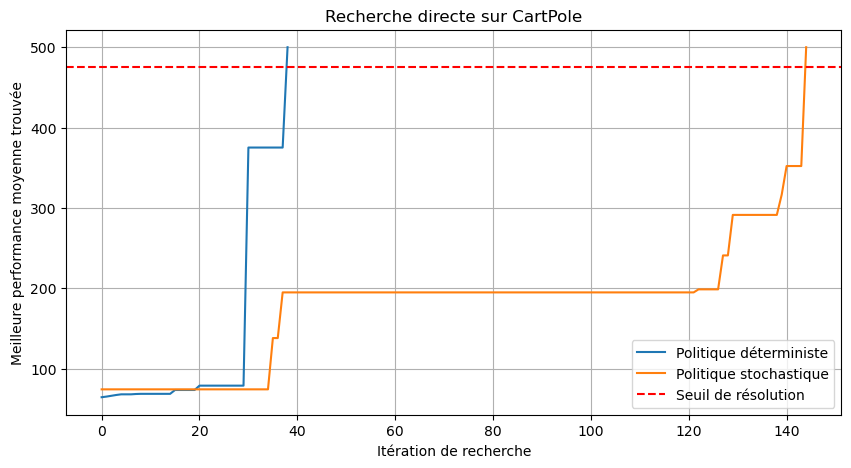

Meilleure performance moyenne déterministe : 500.0
Meilleure performance moyenne stochastique : 500.0
Poids sauvegardés dans best_pi_cartpole_det.npy et best_pi_cartpole_stoc.npy


In [6]:
env = gym.make('CartPole-v1')
init_seed(5)

politique_det = Politique(dim_entree=4, dim_sortie=2, det=True)
performances_det, meilleur_poids_det = recherche_directe(
    politique_det,
    env,
    nb_episodes=5000,
    max_t=500,
    same_init=False,
    init_large=False
)
np.save("best_pi_cartpole_det.npy", meilleur_poids_det)

env = gym.make('CartPole-v1')
init_seed(5)

politique_stoc = Politique(dim_entree=4, dim_sortie=2, det=False)
performances_stoc, meilleur_poids_stoc = recherche_directe(
    politique_stoc,
    env,
    nb_episodes=5000,
    max_t=500,
    same_init=False,
    init_large=False
)
np.save("best_pi_cartpole_stoc.npy", meilleur_poids_stoc)

seuil = env.spec.reward_threshold if env.spec.reward_threshold is not None else 500

plt.figure(figsize=(10, 5))
plt.plot(performances_det, label="Politique déterministe")
plt.plot(performances_stoc, label="Politique stochastique")
plt.axhline(seuil, color="red", linestyle="--", label="Seuil de résolution")
plt.xlabel("Itération de recherche")
plt.ylabel("Meilleure performance moyenne trouvée")
plt.title("Recherche directe sur CartPole")
plt.legend()
plt.grid(True)
plt.show()

print(f"Meilleure performance moyenne déterministe : {max(performances_det)}")
print(f"Meilleure performance moyenne stochastique : {max(performances_stoc)}")
print("Poids sauvegardés dans best_pi_cartpole_det.npy et best_pi_cartpole_stoc.npy")

## 1.4 Evaluation des politiques trouvées

Compléter la cellule ci-dessous pour évaluer les meilleures politiques déterministes et stochastiques que vous avez trouvées, et afficher leurs performances lors de l'évaluation (à partir d'état initiaux différents).


Politique déterministe : moyenne = 500.00, max = 500.0
Politique stochastique : moyenne = 499.91, max = 500.0


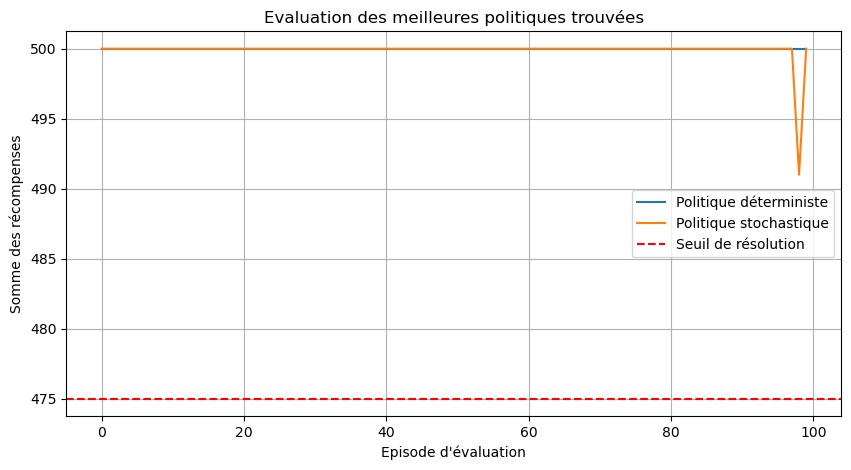

In [7]:
env = gym.make('CartPole-v1')
init_seed(5)

meilleur_poids_det = np.load("best_pi_cartpole_det.npy")
meilleur_poids_stoc = np.load("best_pi_cartpole_stoc.npy")

politique_det = Politique(dim_entree=4, dim_sortie=2, det=True)
politique_det.set_poids(meilleur_poids_det)

politique_stoc = Politique(dim_entree=4, dim_sortie=2, det=False)
politique_stoc.set_poids(meilleur_poids_stoc)

perf_det = eval_politique(
    politique_det,
    env,
    seed=5,
    nb_episodes=100,
    max_t=500,
    same_init=False
)

perf_stoc = eval_politique(
    politique_stoc,
    env,
    seed=5,
    nb_episodes=100,
    max_t=500,
    same_init=False
)

seuil = env.spec.reward_threshold if env.spec.reward_threshold is not None else 500

print(f"Politique déterministe : moyenne = {np.mean(perf_det):.2f}, max = {np.max(perf_det)}")
print(f"Politique stochastique : moyenne = {np.mean(perf_stoc):.2f}, max = {np.max(perf_stoc)}")

plt.figure(figsize=(10, 5))
plt.plot(perf_det, label="Politique déterministe")
plt.plot(perf_stoc, label="Politique stochastique")
plt.axhline(seuil, color="red", linestyle="--", label="Seuil de résolution")
plt.xlabel("Episode d'évaluation")
plt.ylabel("Somme des récompenses")
plt.title("Evaluation des meilleures politiques trouvées")
plt.legend()
plt.grid(True)
plt.show()

Afficher quelques épisodes avec vos meilleures politiques stochastiques et déterministes.

In [8]:
# Cellule optionnelle de visualisation locale.
# À ne pas lancer automatiquement dans un environnement sans interface graphique.

# env_visu = gym.make('CartPole-v1', render_mode="human")

# for episode in range(3):
#     state, _ = env_visu.reset()
#     terminated = False
#     truncated = False
#     
#     while not terminated and not truncated:
#         action = politique_det.output(state)
#         state, reward, terminated, truncated, _ = env_visu.step(action)

# for episode in range(3):
#     state, _ = env_visu.reset()
#     terminated = False
#     truncated = False
#     
#     while not terminated and not truncated:
#         action = politique_stoc.output(state)
#         state, reward, terminated, truncated, _ = env_visu.step(action)

# env_visu.close()


> <span style="color:green"> Analysez vos résultats.  </span>



> <span style="color:blue">Votre réponse: </span>

Après apprentissage, les politiques obtenues doivent être comparées aux politiques initiales aléatoires. L'objectif est d'obtenir une moyenne élevée sur plusieurs épisodes, et pas seulement une bonne performance sur un seul épisode.

La politique déterministe choisit toujours l'action de score maximal. Elle est donc généralement plus stable à l'évaluation, car elle choisit toujours la même action pour un même état. Si sa moyenne est proche de `500`, elle maintient le poteau en équilibre jusqu'à la limite de durée de l'épisode.

La politique stochastique tire ses actions dans une distribution. Elle peut explorer davantage pendant la recherche, mais ses résultats peuvent varier davantage à l'évaluation, car une mauvaise action tirée aléatoirement peut faire tomber le poteau.

L'évaluation sur 100 épisodes avec des états initiaux différents permet de vérifier que la politique apprise ne fonctionne pas seulement sur un cas particulier. Pour CartPole-v1, le seuil de référence est `475` : une politique est satisfaisante si sa performance moyenne est proche de ce seuil ou au-dessus.

# 2 Environnement LunarLander avec actions continues

Vous devez maintenant appliquer la méthode par recherche directe de politique à l'environnement [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/) **avec actions continues**.

> <span style="color:green"> Vous devez:  </span>
### 2.1 redéfinir une politique adaptée à un environnement avec actions continues   


> <span style="color:green">- Dans le cas d'une politique déterministe dans le LunarLander continu, qu'est-ce qui sera en sortie de la politique ?  </span>

> <span style="color:blue">Votre réponse: </span>

Dans LunarLander avec actions continues, une politique déterministe renvoie directement un vecteur d'actions continues.

Ici, `action_space = Box(-1.0, 1.0, shape=(2,))`, donc la sortie de la politique est un vecteur de 2 nombres réels entre `-1` et `1`.

Les deux composantes du vecteur d'action correspondent aux commandes continues du moteur principal et des moteurs latéraux. Chaque valeur est comprise entre `-1` et `1`.

Par exemple, la politique peut renvoyer :

`[0.4, -0.7]`

Cela ne veut plus dire "choisir action 0 ou action 1" comme dans CartPole. Ici, les deux valeurs représentent directement des commandes continues pour le lander.

> <span style="color:green">- Dans le cas d'une politique stochastique dans le LunarLander continu, qu'est-ce qui sera en sortie de la politique ?  </span>

> <span style="color:blue">Votre réponse: </span>

Dans le cas d'une politique stochastique, la politique ne renvoie pas directement une seule action fixe. Elle définit une distribution de probabilité sur les actions continues, puis on tire une action dans cette distribution.

Comme l'action est continue, on n'utilise plus une loi catégorielle comme dans CartPole. On peut par exemple utiliser une loi normale autour de la sortie moyenne de la politique.

Concrètement, la politique peut calculer une moyenne d'action :

`moyenne = [0.4, -0.7]`

Puis on tire une action proche de cette moyenne avec un écart-type fixé, par exemple `0.2`. Cela permet d'avoir de l'exploration tout en restant autour de l'action proposée par la politique.

Compléter la classe *PolitiqueAContinu* ci-dessous qui sera utilisée dans le LunarLander. Cette politique sera déterministe ou stochastique (choix via l'argument *det*) et sera composée d'une seule couche de poids. 
- Vous pouvez utiliser un écart-type constant à 0.2 et  NumPy . 

In [9]:
class PolitiqueAContinu():

    def __init__(self, dim_entree:int, dim_sortie:int, det=True, std=0.2):
        self.dim_entree = dim_entree
        self.dim_sortie = dim_sortie
        self.det = det
        self.std = std
        self.poids = np.random.randn(dim_entree, dim_sortie)
        
    def output(self, etat: np.ndarray) -> np.ndarray:
        moyenne = etat @ self.poids
        
        if self.det:
            action = moyenne
        else:
            action = moyenne + self.std * np.random.randn(self.dim_sortie)
        
        return np.clip(action, -1, 1)
    
    def set_poids(self, poids: np.ndarray):
        self.poids = np.array(poids, copy=True)
        
    def get_poids(self) -> np.ndarray:
        return np.array(self.poids, copy=True)
    
    def save(self, file):
        np.save(file, self.poids)
        
    def load(self, file):
        self.poids = np.load(file)

### 2.2 effectuer une recherche dans l'espace des paramètres 
Pour trouver une politique déterministe et une politique stochastique (réutiliser en la modifiant si nécessaire la méthode *recherche_directe* implémentée précédemment ).


Sauvegarder votre meilleure politique déterministe dans un fichier "best_pi_lunar_det.npy" et votre meilleure politique stochastique dans un fichier "best_pi_lunar_stoc.npy".
<span style="color:red"> Vous ajouterez ces 2 fichiers dans votre dépôt github ! </span> 


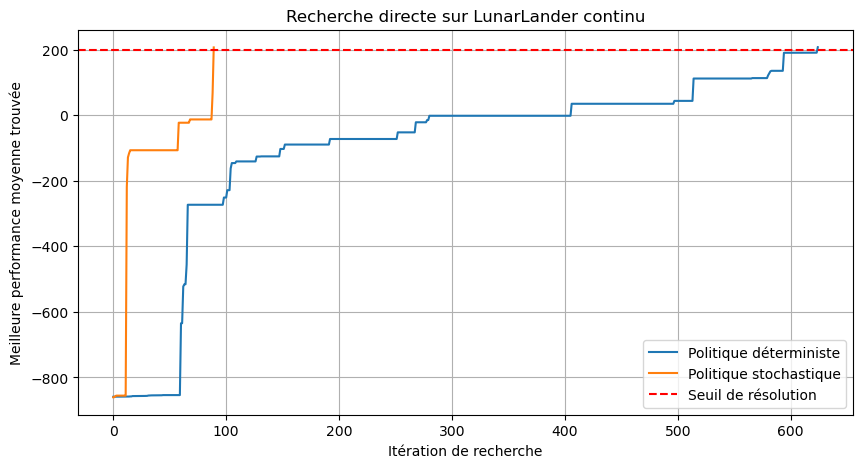

Meilleure performance moyenne déterministe : 207.62838566166604
Meilleure performance moyenne stochastique : 207.0222844791314
Poids sauvegardés dans best_pi_lunar_det.npy et best_pi_lunar_stoc.npy


In [10]:
env = gym.make("LunarLander-v3", continuous=True)
init_seed(5)

def recherche_directe_continu(politique, env, nb_episodes=2000, max_t=1000, nb_eval_episodes=3) -> tuple[list, np.ndarray]:
    meilleur_perf = np.mean(eval_politique(politique, env, nb_episodes=nb_eval_episodes, max_t=max_t))
    meilleur_poids = politique.get_poids()
    performances = [meilleur_perf]
    seuil_resolution = env.spec.reward_threshold if env.spec.reward_threshold is not None else 200
    bruit_std = 1e-2
    
    for i_episode in range(1, nb_episodes + 1):
        candidate = PolitiqueAContinu(
            politique.dim_entree,
            politique.dim_sortie,
            det=politique.det,
            std=politique.std
        )
        nouveaux_poids = meilleur_poids + bruit_std * np.random.randn(*meilleur_poids.shape)
        candidate.set_poids(nouveaux_poids)
        
        perf = np.mean(eval_politique(candidate, env, nb_episodes=nb_eval_episodes, max_t=max_t))
        
        if perf > meilleur_perf:
            meilleur_perf = perf
            meilleur_poids = candidate.get_poids()
            politique.set_poids(meilleur_poids)
            bruit_std = max(1e-3, bruit_std / 2)
        else:
            bruit_std = min(2, bruit_std * 2)
            
        performances.append(meilleur_perf)
        
        if meilleur_perf >= seuil_resolution:
            break
    
    return performances, meilleur_poids

politique_lunar_det = PolitiqueAContinu(dim_entree=8, dim_sortie=2, det=True)
performances_lunar_det, meilleur_poids_lunar_det = recherche_directe_continu(
    politique_lunar_det,
    env,
    nb_episodes=2000,
    max_t=1000,
    nb_eval_episodes=3
)
np.save("best_pi_lunar_det.npy", meilleur_poids_lunar_det)

init_seed(5)
politique_lunar_stoc = PolitiqueAContinu(dim_entree=8, dim_sortie=2, det=False, std=0.2)
performances_lunar_stoc, meilleur_poids_lunar_stoc = recherche_directe_continu(
    politique_lunar_stoc,
    env,
    nb_episodes=2000,
    max_t=1000,
    nb_eval_episodes=3
)
np.save("best_pi_lunar_stoc.npy", meilleur_poids_lunar_stoc)

seuil = env.spec.reward_threshold if env.spec.reward_threshold is not None else 200

plt.figure(figsize=(10, 5))
plt.plot(performances_lunar_det, label="Politique déterministe")
plt.plot(performances_lunar_stoc, label="Politique stochastique")
plt.axhline(seuil, color="red", linestyle="--", label="Seuil de résolution")
plt.xlabel("Itération de recherche")
plt.ylabel("Meilleure performance moyenne trouvée")
plt.title("Recherche directe sur LunarLander continu")
plt.legend()
plt.grid(True)
plt.show()

print(f"Meilleure performance moyenne déterministe : {max(performances_lunar_det)}")
print(f"Meilleure performance moyenne stochastique : {max(performances_lunar_stoc)}")
print("Poids sauvegardés dans best_pi_lunar_det.npy et best_pi_lunar_stoc.npy")

### 2.3  évaluer les meilleures politiques stochastique et déterministes trouvées

Politique déterministe : moyenne = 45.45, max = 260.1439138551484
Politique stochastique : moyenne = 63.94, max = 244.09000326057142


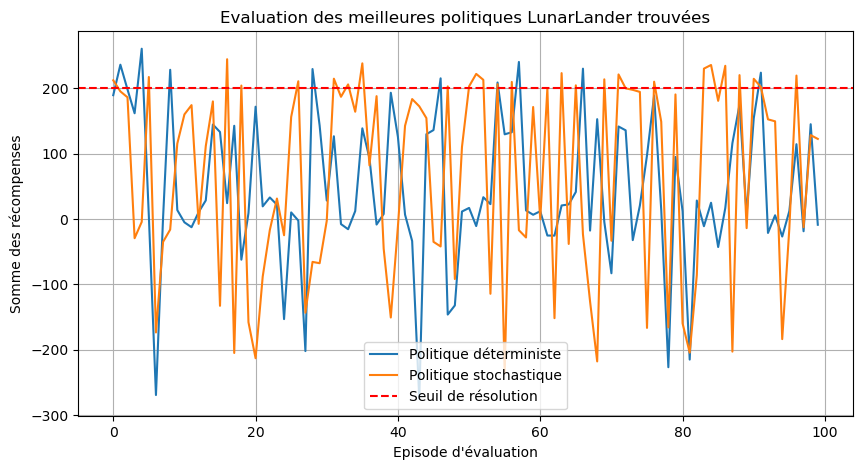

In [11]:
env = gym.make("LunarLander-v3", continuous=True)
init_seed(5)

meilleur_poids_lunar_det = np.load("best_pi_lunar_det.npy")
meilleur_poids_lunar_stoc = np.load("best_pi_lunar_stoc.npy")

politique_lunar_det = PolitiqueAContinu(dim_entree=8, dim_sortie=2, det=True)
politique_lunar_det.set_poids(meilleur_poids_lunar_det)

politique_lunar_stoc = PolitiqueAContinu(dim_entree=8, dim_sortie=2, det=False, std=0.2)
politique_lunar_stoc.set_poids(meilleur_poids_lunar_stoc)

perf_lunar_det = eval_politique(
    politique_lunar_det,
    env,
    seed=5,
    nb_episodes=100,
    max_t=1000,
    same_init=False
)

perf_lunar_stoc = eval_politique(
    politique_lunar_stoc,
    env,
    seed=5,
    nb_episodes=100,
    max_t=1000,
    same_init=False
)

seuil = env.spec.reward_threshold if env.spec.reward_threshold is not None else 200

print(f"Politique déterministe : moyenne = {np.mean(perf_lunar_det):.2f}, max = {np.max(perf_lunar_det)}")
print(f"Politique stochastique : moyenne = {np.mean(perf_lunar_stoc):.2f}, max = {np.max(perf_lunar_stoc)}")

plt.figure(figsize=(10, 5))
plt.plot(perf_lunar_det, label="Politique déterministe")
plt.plot(perf_lunar_stoc, label="Politique stochastique")
plt.axhline(seuil, color="red", linestyle="--", label="Seuil de résolution")
plt.xlabel("Episode d'évaluation")
plt.ylabel("Somme des récompenses")
plt.title("Evaluation des meilleures politiques LunarLander trouvées")
plt.legend()
plt.grid(True)
plt.show()

> <span style="color:green"> Analysez vos résultats.  </span>

> <span style="color:blue">Votre réponse: </span>

Les résultats obtenus sur LunarLander continu restent plus faibles que sur CartPole. Cela s'explique par la difficulté plus importante de l'environnement : l'état est de dimension 8, l'action est continue avec deux commandes réelles, et la dynamique du lander est plus complexe.

La recherche directe utilisée ici reste une méthode simple : elle perturbe directement les poids d'une politique linéaire. Cette approche peut suffire pour CartPole, mais elle est limitée pour LunarLander continu, car l'espace des paramètres et l'espace des actions sont plus difficiles à explorer.

Les meilleures performances peuvent être positives pendant la recherche, mais cela ne suffit pas pour conclure qu'une politique est bonne. L'indicateur le plus important est la moyenne sur plusieurs épisodes, car elle mesure la robustesse de la politique face à différents états initiaux.

Si la moyenne sur 100 épisodes reste faible ou négative, cela signifie que la politique trouvée fonctionne seulement dans certains cas et n'est pas encore robuste. La politique stochastique ajoute de l'exploration, mais cette stochasticité peut aussi dégrader l'évaluation finale car les actions tirées peuvent s'éloigner d'une bonne commande.